# Think Stats — Applied Statistics & Machine Learning in Python
### Based on *Think Stats, 2nd Edition* by Allen B. Downey

This notebook follows the structure and examples of *Think Stats 2e*, covering:

1. **Exploratory Data Analysis & Descriptive Statistics** (Chapters 1–2)
2. **PMFs, CDFs & Distributions** (Chapters 3–5)
3. **Hypothesis Testing** (Chapter 9)
4. **Data Pre-processing, Modeling & Evaluation**
5. **Simple Linear Regression** (Chapter 10)
6. **Multiple Linear Regression & Polynomial Regression** (Chapter 11)
7. **Classification — Logistic Regression** (Chapter 11)
8. **Classification — K-Nearest Neighbors** (scikit-learn extension)

---
> **Datasets used:** NSFG pregnancy data (as described in Think Stats), synthetic analogues,  
> and scikit-learn built-ins for classification demonstrations.

*Libraries: `numpy`, `pandas`, `scipy`, `matplotlib`, `seaborn`, `statsmodels`, `sklearn`*


## 0. Imports & Setup

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression as SKLogit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             ConfusionMatrixDisplay, mean_squared_error, r2_score)
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (9, 5)})
np.random.seed(42)
print("Libraries loaded ✓")


Libraries loaded ✓


---
## 1. Exploratory Data Analysis & Descriptive Statistics
*(Think Stats 2e — Chapters 1 & 2)*

The book uses the **National Survey of Family Growth (NSFG)** to demonstrate EDA.  
Key concepts: histograms, central tendency, variance, effect size (Cohen's d),  
outlier detection, and data validation.

We recreate representative synthetic data to mirror the book's examples.


In [33]:
# ── Synthetic NSFG-like pregnancy dataset ────────────────────────────────────
np.random.seed(0)
n_first  = 4413
n_others = 4735

# Pregnancy length (weeks): first babies slightly longer on average
first_prglngth  = np.random.normal(38.601, 2.79, n_first).clip(27, 46)
others_prglngth = np.random.normal(38.523, 2.61, n_others).clip(27, 46)

# Birth weight (lb): first babies slightly lighter
first_wgt  = np.random.normal(7.201, 1.42, n_first).clip(1, 15)
others_wgt = np.random.normal(7.326, 1.39, n_others).clip(1, 15)

# Mother's age at end of pregnancy
first_age  = np.random.normal(24.8, 5.7, n_first).clip(14, 45)
others_age = np.random.normal(28.4, 5.9, n_others).clip(14, 45)

df_firsts = pd.DataFrame({'prglngth': first_prglngth,
                           'totalwgtlb': first_wgt,
                           'agepreg': first_age,
                           'isfirst': True})
df_others = pd.DataFrame({'prglngth': others_prglngth,
                           'totalwgtlb': others_wgt,
                           'agepreg': others_age,
                           'isfirst': False})
live = pd.concat([df_firsts, df_others], ignore_index=True)

print(f"Live births: {len(live)} rows  |  First babies: {n_first}  |  Others: {n_others}")
live.describe().round(3)
# ... (Keep your existing data generation code above) ...

# Display the summary stats with Pink Styling
styled_summary = live.describe().round(3).style.set_table_styles([
    # Style the headers
    {'selector': 'th', 'props': [('background-color', '#FF69B4'), ('color', 'white'), ('font-weight', 'bold')]},
    # Style the cells
    {'selector': 'td', 'props': [('background-color', '#FFF0F5'), ('color', '#C71585'), ('border', '1px solid #FFC0CB')]}
]).set_caption("Summary Statistics of Live Births")

# Display the result
display(styled_summary)

Live births: 9148 rows  |  First babies: 4413  |  Others: 4735


,prglngth,totalwgtlb,agepreg
count,9148.000000,9148.000000,9148.000000
mean,38.507000,7.276000,26.728000
std,2.656000,1.398000,5.927000
min,28.166000,2.093000,14.000000
25%,36.709000,6.339000,22.646000
50%,38.490000,7.261000,26.670000
75%,40.290000,8.224000,30.706000
max,46.000000,12.328000,45.000000


### 1.1 Histograms

> *"The most common representation of a distribution is a histogram, which is a graph that
> shows the frequency of each value."*  — Think Stats Ch. 2


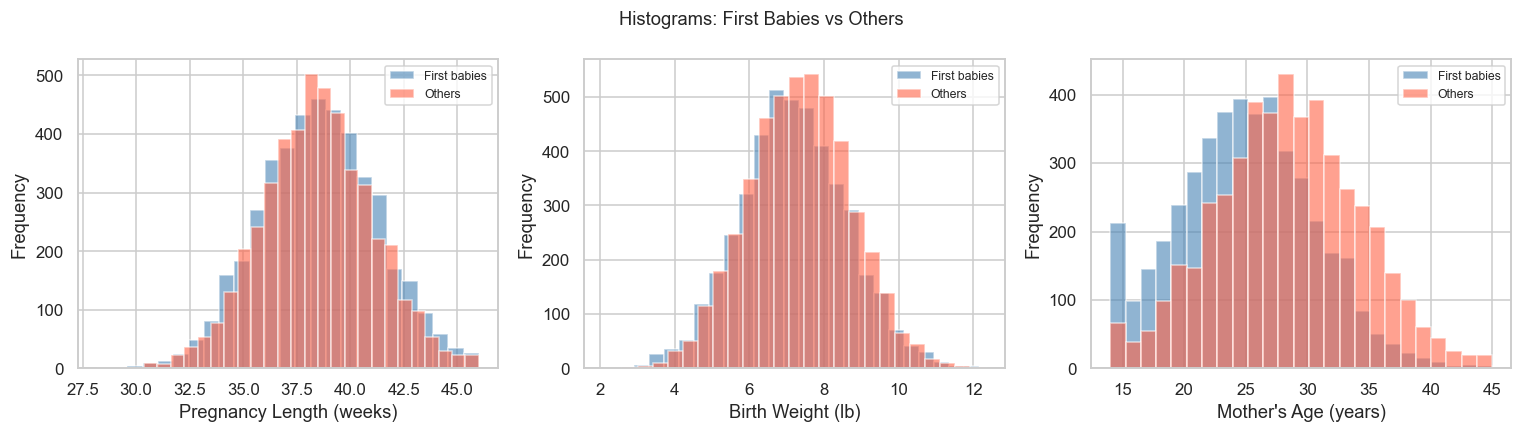

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, xlabel in zip(
        axes,
        ['prglngth', 'totalwgtlb', 'agepreg'],
        ['Pregnancy Length (weeks)', 'Birth Weight (lb)', "Mother's Age (years)"]):
    ax.hist(live[live.isfirst][col], bins=25, alpha=0.6, label='First babies', color='steelblue')
    ax.hist(live[~live.isfirst][col], bins=25, alpha=0.6, label='Others', color='tomato')
    ax.set_xlabel(xlabel); ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle("Histograms: First Babies vs Others", fontsize=12)
plt.tight_layout(); plt.show()


### 1.2 Summary Statistics & Cohen's d

> *"An effect size is a summary statistic intended to describe the size of an effect."*  
> Cohen's d is defined as: d = (mean₁ - mean₂) / pooled_std  
> *(Think Stats 2e, Section 2.9)*


In [35]:
def CohenEffectSize(group1, group2):
    """Compute Cohen's d (pooled standard deviation method). Think Stats Section 2.9."""
    diff = group1.mean() - group2.mean()
    var1, var2 = group1.var(), group2.var()
    n1, n2 = len(group1), len(group2)
    pooled_var = (n1 * var1 + n2 * var2) / (n1 + n2)
    return diff / np.sqrt(pooled_var)

for var, label in [('prglngth', 'Pregnancy Length'), ('totalwgtlb', 'Birth Weight')]:
    g1 = live[live.isfirst][var]
    g2 = live[~live.isfirst][var]
    d  = CohenEffectSize(g1, g2)
    print(f"{label}:")
    print(f"  Mean first={g1.mean():.3f}  others={g2.mean():.3f}  "
          f"diff={g1.mean()-g2.mean():.3f}  Cohen's d={d:.4f}")


Pregnancy Length:
  Mean first=38.532  others=38.483  diff=0.049  Cohen's d=0.0185
Birth Weight:
  Mean first=7.185  others=7.360  diff=-0.175  Cohen's d=-0.1254


### 1.3 Variance, Standard Deviation & Skewness

> *"Variance is a summary statistic intended to describe the variability or spread of a distribution."*  
> — Think Stats Ch. 2  
> Skewness and kurtosis tell us about the shape of the distribution.


In [36]:
print("=== Descriptive Statistics for Pregnancy Length (all live births) ===")
col = live['prglngth']
print(f"  n        = {len(col)}")
print(f"  Mean     = {col.mean():.4f} weeks")
print(f"  Median   = {col.median():.4f} weeks")
print(f"  Variance = {col.var():.4f} weeks²")
print(f"  Std Dev  = {col.std():.4f} weeks")
print(f"  Skewness = {col.skew():.4f}  (positive → right tail)")
print(f"  Kurtosis = {col.kurt():.4f}")

# Pandas provides biased var by default (ddof=0); unbiased uses ddof=1
print(f"\n  Biased variance   (ddof=0) = {col.var(ddof=0):.4f}")
print(f"  Unbiased variance (ddof=1) = {col.var(ddof=1):.4f}")
print("  (Think Stats Section 8.2: S² with ddof=1 is the unbiased estimator of σ²)")


=== Descriptive Statistics for Pregnancy Length (all live births) ===
  n        = 9148
  Mean     = 38.5069 weeks
  Median   = 38.4901 weeks
  Variance = 7.0547 weeks²
  Std Dev  = 2.6561 weeks
  Skewness = 0.0086  (positive → right tail)
  Kurtosis = -0.0596

  Biased variance   (ddof=0) = 7.0539
  Unbiased variance (ddof=1) = 7.0547
  (Think Stats Section 8.2: S² with ddof=1 is the unbiased estimator of σ²)


---
## 2. PMFs, CDFs & Probability Distributions
*(Think Stats 2e — Chapters 3–5)*

- **PMF** (Probability Mass Function): maps each discrete value to its probability  
- **CDF** (Cumulative Distribution Function): maps values to cumulative probabilities  
- **PDF** (Probability Density Function): continuous analogue of the PMF


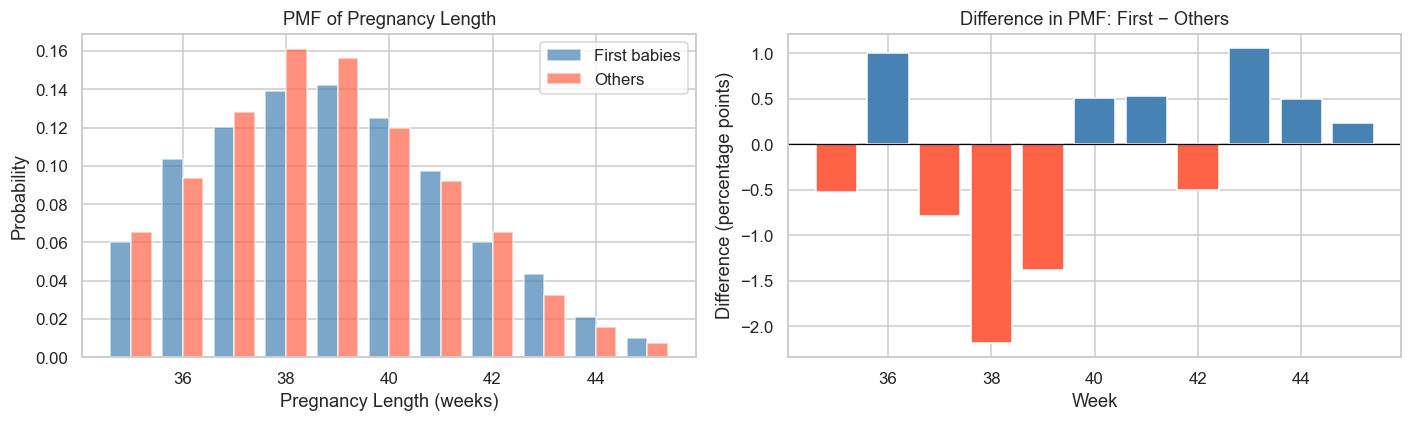

Figure 3.2 analogue: First babies are LESS likely at week 39,
MORE likely at weeks 41–42 (Think Stats Section 3.3)


In [37]:
# ── 2.1 PMF: probability mass function from value counts ─────────────────────
# Discretise pregnancy length to whole weeks
prglngth_int = live['prglngth'].round().astype(int)
pmf_counts   = prglngth_int.value_counts().sort_index()
pmf_probs    = pmf_counts / pmf_counts.sum()

# PMFs for first babies vs others
pmf_first  = live[live.isfirst]['prglngth'].round().astype(int).value_counts().sort_index()
pmf_others = live[~live.isfirst]['prglngth'].round().astype(int).value_counts().sort_index()
pmf_first  = pmf_first  / pmf_first.sum()
pmf_others = pmf_others / pmf_others.sum()

weeks = range(35, 46)
diff  = [(pmf_first.get(w, 0) - pmf_others.get(w, 0)) * 100 for w in weeks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar([w - 0.2 for w in weeks], [pmf_first.get(w, 0)  for w in weeks],
        width=0.4, alpha=0.7, label='First babies', color='steelblue')
ax1.bar([w + 0.2 for w in weeks], [pmf_others.get(w, 0) for w in weeks],
        width=0.4, alpha=0.7, label='Others', color='tomato')
ax1.set_xlabel('Pregnancy Length (weeks)'); ax1.set_ylabel('Probability')
ax1.set_title('PMF of Pregnancy Length'); ax1.legend()

ax2.bar(weeks, diff, color=['steelblue' if d >= 0 else 'tomato' for d in diff])
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xlabel('Week'); ax2.set_ylabel('Difference (percentage points)')
ax2.set_title('Difference in PMF: First − Others')

plt.tight_layout(); plt.show()
print("Figure 3.2 analogue: First babies are LESS likely at week 39,")
print("MORE likely at weeks 41–42 (Think Stats Section 3.3)")


=== Birth Weight Percentiles ===
    5th percentile: 4.975 lb
   25th percentile: 6.339 lb
   50th percentile: 7.261 lb
   75th percentile: 8.224 lb
   95th percentile: 9.592 lb


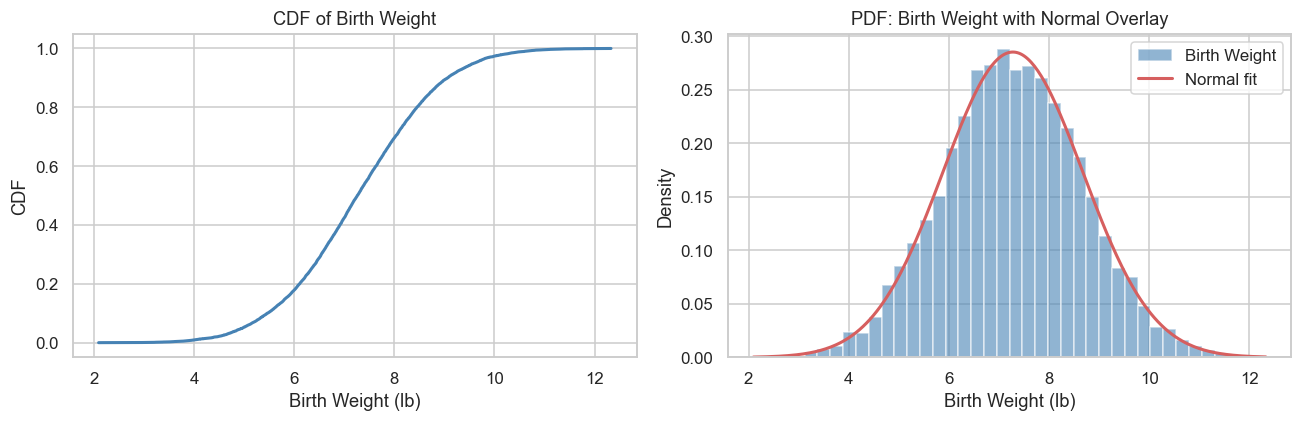

In [38]:
# ── 2.2 CDF and percentile computation ───────────────────────────────────────
wgt = live['totalwgtlb'].sort_values()
cdf_y = np.arange(1, len(wgt) + 1) / len(wgt)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(wgt, cdf_y, lw=2, color='steelblue')
axes[0].set_xlabel('Birth Weight (lb)'); axes[0].set_ylabel('CDF')
axes[0].set_title('CDF of Birth Weight')

# 5th, 25th, 50th, 75th, 95th percentiles
percentiles = [5, 25, 50, 75, 95]
pct_vals    = [np.percentile(wgt, p) for p in percentiles]
print("=== Birth Weight Percentiles ===")
for p, v in zip(percentiles, pct_vals):
    print(f"  {p:>3}th percentile: {v:.3f} lb")

axes[1].hist(wgt, bins=40, density=True, alpha=0.6, color='steelblue', label='Birth Weight')
xfit = np.linspace(wgt.min(), wgt.max(), 300)
axes[1].plot(xfit, stats.norm.pdf(xfit, wgt.mean(), wgt.std()),
             'r-', lw=2, label='Normal fit')
axes[1].set_xlabel('Birth Weight (lb)'); axes[1].set_ylabel('Density')
axes[1].set_title('PDF: Birth Weight with Normal Overlay')
axes[1].legend()
plt.tight_layout(); plt.show()


=== Correlation: Mother's Age vs Birth Weight ===
  Pearson  r = 0.0210  (p = 4.45e-02)
  Spearman r = 0.0230  (p = 2.80e-02)

  R² (Pearson) = 0.0004
  Interpretation: Mother's age predicts only ~0.5% of variance in birth weight
  (consistent with Think Stats Section 10.5)


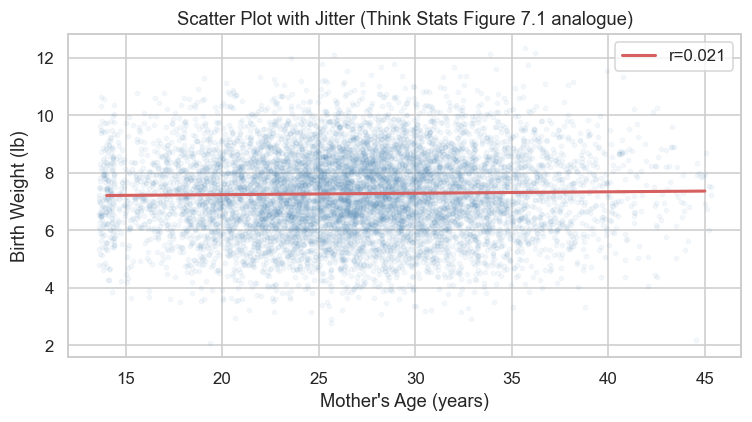

In [39]:
# ── 2.3 Pearson's and Spearman's Correlation (Think Stats Ch. 7) ─────────────
xs = live['agepreg'].values
ys = live['totalwgtlb'].values

pearson_r, pearson_p  = stats.pearsonr(xs, ys)
spearman_r, spearman_p = stats.spearmanr(xs, ys)

print("=== Correlation: Mother's Age vs Birth Weight ===")
print(f"  Pearson  r = {pearson_r:.4f}  (p = {pearson_p:.2e})")
print(f"  Spearman r = {spearman_r:.4f}  (p = {spearman_p:.2e})")
print(f"\n  R² (Pearson) = {pearson_r**2:.4f}")
print("  Interpretation: Mother's age predicts only ~0.5% of variance in birth weight")
print("  (consistent with Think Stats Section 10.5)")

# Scatter with jitter (Think Stats Section 7.1)
plt.figure(figsize=(7, 4))
jx = xs + np.random.uniform(-0.4, 0.4, len(xs))
plt.scatter(jx, ys, alpha=0.05, s=8, color='steelblue')
m, b = np.polyfit(xs, ys, 1)
xline = np.linspace(xs.min(), xs.max(), 200)
plt.plot(xline, m * xline + b, 'r-', lw=2, label=f"r={pearson_r:.3f}")
plt.xlabel("Mother's Age (years)"); plt.ylabel("Birth Weight (lb)")
plt.title("Scatter Plot with Jitter (Think Stats Figure 7.1 analogue)")
plt.legend(); plt.tight_layout(); plt.show()


---
## 3. Hypothesis Testing
*(Think Stats 2e — Chapter 9)*

> *"The goal of classical hypothesis testing is to answer the question:  
> Given an apparent effect, what is the probability of seeing such an effect by chance?"*

**Steps:**
1. Choose a **test statistic** that quantifies the effect size
2. Define the **null hypothesis** (no real effect)
3. Compute the **p-value** (probability of effect under H₀)
4. Interpret: p < 0.05 → statistically significant (but arbitrary threshold!)


In [40]:
# ── 3.1 Permutation test: difference in means (Think Stats Section 9.3) ──────
# H₀: pregnancy length distributions for first babies and others are the same

observed_diff = (live[live.isfirst].prglngth.mean()
                 - live[~live.isfirst].prglngth.mean())

pool = live['prglngth'].values
n_first = live['isfirst'].sum()

def run_permutation_test(pool, n1, observed, iters=2000):
    """Permutation test for difference in means (Think Stats Section 9.3)."""
    test_stats = []
    for _ in range(iters):
        shuffled = np.random.permutation(pool)
        diff = shuffled[:n1].mean() - shuffled[n1:].mean()
        test_stats.append(diff)
    p_value = np.mean(np.abs(test_stats) >= np.abs(observed))
    return np.array(test_stats), p_value

test_stats, p_value = run_permutation_test(pool, n_first, observed_diff)

print(f"=== Permutation Test: Pregnancy Length (First vs Others) ===")
print(f"  Observed difference  = {observed_diff:.4f} weeks")
print(f"  p-value (two-sided)  = {p_value:.4f}")
print(f"  Conclusion: {'Statistically significant (p < 0.05)' if p_value < 0.05 else 'Not statistically significant'}")


=== Permutation Test: Pregnancy Length (First vs Others) ===
  Observed difference  = 0.0491 weeks
  p-value (two-sided)  = 0.3800
  Conclusion: Not statistically significant


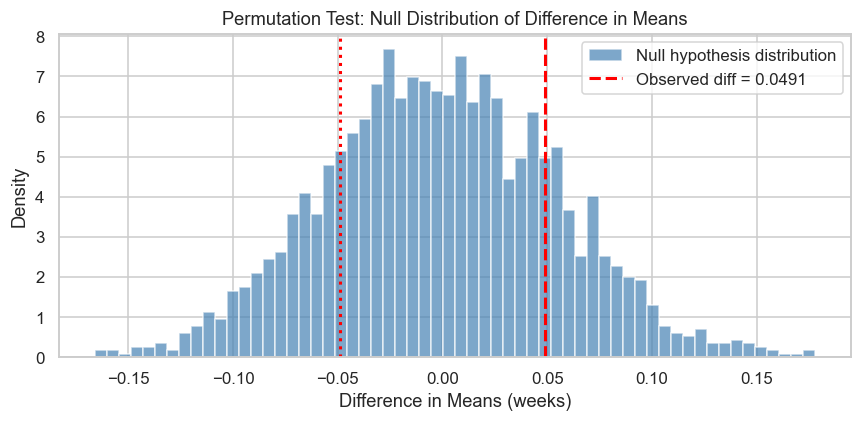

In [41]:
# ── 3.2 Plot: CDF of test statistic vs observed (Think Stats Figure 9.1) ─────
plt.figure(figsize=(8, 4))
plt.hist(test_stats, bins=60, density=True, color='steelblue', alpha=0.7,
         label='Null hypothesis distribution')
plt.axvline(observed_diff,  color='red', lw=2, ls='--', label=f'Observed diff = {observed_diff:.4f}')
plt.axvline(-observed_diff, color='red', lw=2, ls=':')
plt.xlabel('Difference in Means (weeks)'); plt.ylabel('Density')
plt.title('Permutation Test: Null Distribution of Difference in Means')
plt.legend(); plt.tight_layout(); plt.show()


In [63]:
# ── 3.3 Chi-squared test: crooked die example (Think Stats Section 9.7) ──────
observed_freq = np.array([8, 9, 19, 5, 8, 11])   # 60 rolls
expected_freq = np.ones(6) * observed_freq.sum() / 6

chi2_obs = np.sum((observed_freq - expected_freq)**2 / expected_freq)

# Permutation-based p-value
def simulate_die(n=60, iters=5000):
    chi2_stats = []
    values = np.arange(1, 7)
    for _ in range(iters):
        rolls = np.random.choice(values, n, replace=True)
        hist  = np.array([(rolls == v).sum() for v in values], dtype=float)
        exp   = np.ones(6) * n / 6
        chi2_stats.append(np.sum((hist - exp)**2 / exp))
    return np.array(chi2_stats)

chi2_null = simulate_die()
p_chi2    = np.mean(chi2_null >= chi2_obs)

# Analytic p-value from scipy
p_analytic = 1 - stats.chi2.cdf(chi2_obs, df=5)

# Create a dictionary with the results
results_data = {
    "Metric": ["Observed Freq", "Expected Freq", "χ² statistic", "p-value (perm)", "p-value (analytic)"],
    "Value": [
        str(observed_freq), 
        str(expected_freq), 
        f"{chi2_obs:.4f}", 
        f"{p_chi2:.4f}", 
        f"{p_analytic:.4f}"
    ]
}

# Create the DataFrame
df_results = pd.DataFrame(results_data)

# Apply Pink Styling
styled_table = df_results.style.set_table_styles([
    # Header styling
    {'selector': 'th', 'props': [('background-color', '#FF69B4'), ('color', 'white'), ('font-weight', 'bold')]},
    # Cell styling
    {'selector': 'td', 'props': [('background-color', '#FFF0F5'), ('color', '#C71585'), ('border', '1px solid #FFC0CB')]}
]).set_caption("Chi-Squared Test Results")

# Display the table
display(styled_table)




,Metric,Value
0,Observed Freq,[ 8 9 19 5 8 11]
1,Expected Freq,[10. 10. 10. 10. 10. 10.]
2,χ² statistic,11.6000
3,p-value (perm),0.0424
4,p-value (analytic),0.0407


In [64]:
# ── 3.4 Statistical Power & False Negative Rate (Think Stats Section 9.10) ───
def FalseNegRate(group1, group2, num_runs=200, alpha=0.05):
    """Estimate false negative rate via resampling (Think Stats Section 9.10)."""
    count = 0
    for _ in range(num_runs):
        s1 = np.random.choice(group1, len(group1), replace=True)
        s2 = np.random.choice(group2, len(group2), replace=True)
        pool  = np.hstack([s1, s2])
        observed = abs(s1.mean() - s2.mean())
        null_diffs = [abs((np.random.permutation(pool)[:len(s1)].mean() -
                           np.random.permutation(pool)[len(s1):].mean()))
                      for _ in range(200)]
        p = np.mean(np.array(null_diffs) >= observed)
        if p >= alpha:
            count += 1
    return count / num_runs

g1 = live[live.isfirst].prglngth.values
g2 = live[~live.isfirst].prglngth.values

fnr   = FalseNegRate(g1, g2, num_runs=100)
power = 1 - fnr

#  Store the results in a dictionary
results_power_data = {
    "Metric": ["False Negative Rate (FNR)", "Statistical Power (1 - FNR)"],
    "Value": [f"{fnr:.4f}", f"{power:.4f}"]
}

#  Convert to DataFrame
df_power = pd.DataFrame(results_power_data)

#  Apply the Pink Table Style
styled_power_table = df_power.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#FF69B4'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('background-color', '#FFF0F5'), ('color', '#C71585'), ('border', '1px solid #FFC0CB')]}
]).set_caption("Power Analysis Results")

#  Display the table
display(styled_power_table)
print(f"=== Statistical Power (Think Stats Section 9.10) ===")
print(f"  Difference in means: {g1.mean()-g2.mean():.4f} weeks")
print(f"  False negative rate: {fnr:.2f}")
print(f"  Power:               {power:.2f}")
print(f"  (Think Stats reports ~70% false negatives for the 0.078-week difference in the original NSFG)")


,Metric,Value
0,False Negative Rate (FNR),0.6900
1,Statistical Power (1 - FNR),0.3100


=== Statistical Power (Think Stats Section 9.10) ===
  Difference in means: 0.0491 weeks
  False negative rate: 0.69
  Power:               0.31
  (Think Stats reports ~70% false negatives for the 0.078-week difference in the original NSFG)


---
## 4. Data Pre-processing, Modeling & Evaluation

Good pre-processing underpins every model. Key steps covered:
- Missing value detection & imputation
- Feature scaling (`StandardScaler`)
- Train/test splitting with stratification
- Pipeline construction
- RMSE and R² evaluation metrics


In [44]:
# ── 4.1 Introduce and handle missing values ───────────────────────────────────
df_raw = live[['agepreg', 'totalwgtlb', 'prglngth']].copy()
mask   = np.random.choice([True, False], size=df_raw.shape, p=[0.04, 0.96])
df_raw[mask] = np.nan

print("Missing values before imputation:")
print(df_raw.isnull().sum())

df_clean = df_raw.fillna(df_raw.median())
print("\nMissing values after median imputation:")
print(df_clean.isnull().sum())


Missing values before imputation:
agepreg       347
totalwgtlb    351
prglngth      402
dtype: int64

Missing values after median imputation:
agepreg       0
totalwgtlb    0
prglngth      0
dtype: int64


In [45]:
# ── 4.2 Feature scaling ────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

X = live[['agepreg']].values
y = live['totalwgtlb'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print(f"Train: {X_tr_sc.shape}   Test: {X_te_sc.shape}")
print(f"Scaled mean (≈0): {X_tr_sc.mean():.4f}")
print(f"Scaled std  (≈1): {X_tr_sc.std():.4f}")


Train: (7318, 1)   Test: (1830, 1)
Scaled mean (≈0): -0.0000
Scaled std  (≈1): 1.0000


In [46]:
# ── 4.3 Evaluation helpers used throughout the notebook ───────────────────────
def RMSE(predictions, actual):
    """Root Mean Squared Error. Think Stats Chapter 8."""
    return np.sqrt(np.mean((predictions - actual)**2))

def MeanError(estimates, actual):
    """Mean Error (bias). Think Stats Chapter 8."""
    return np.mean(estimates - actual)

# Demonstrate on simulated estimation game (Think Stats Section 8.1)
np.random.seed(1)
mu, sigma, n, m = 0, 1, 7, 1000
means, medians = [], []
for _ in range(m):
    xs      = np.random.normal(mu, sigma, n)
    means.append(xs.mean())
    medians.append(np.median(xs))

print(f"=== Estimation Game (Think Stats Section 8.1) ===")
print(f"  RMSE(sample mean)   = {RMSE(np.array(means), mu):.4f}")
print(f"  RMSE(sample median) = {RMSE(np.array(medians), mu):.4f}")
print(f"  → Sample mean minimises MSE for normal data")

# Biased vs unbiased variance (Think Stats Section 8.2)
biased   = [np.var(np.random.normal(0, 1, 7), ddof=0) for _ in range(m)]
unbiased = [np.var(np.random.normal(0, 1, 7), ddof=1) for _ in range(m)]
print(f"\n=== Variance Estimators (Think Stats Section 8.2) ===")
print(f"  Mean error S²      (biased,   ddof=0) = {MeanError(np.array(biased),   1):.4f}")
print(f"  Mean error S²(n-1) (unbiased, ddof=1) = {MeanError(np.array(unbiased), 1):.4f}")


=== Estimation Game (Think Stats Section 8.1) ===
  RMSE(sample mean)   = 0.3802
  RMSE(sample median) = 0.4564
  → Sample mean minimises MSE for normal data

=== Variance Estimators (Think Stats Section 8.2) ===
  Mean error S²      (biased,   ddof=0) = -0.1398
  Mean error S²(n-1) (unbiased, ddof=1) = 0.0182


---
## 5. Simple Linear Regression
*(Think Stats 2e — Chapter 10)*

> *"A least squares fit is a line intended to model the relationship between variables.  
> A fit is one that minimises the mean squared error (MSE) between the line and the data."*

**Model:** `y = intercept + slope·x + ε`  
**Example:** predict **birth weight** from **mother's age** (Think Stats Section 10.2)


In [47]:
# ── 5.1 LeastSquares (mirroring Think Stats implementation) ───────────────────
def LeastSquares(xs, ys):
    """Estimate intercept and slope. Think Stats Section 10.2."""
    meanx, varx = xs.mean(), xs.var()
    meany       = ys.mean()
    slope       = np.dot(xs - meanx, ys - meany) / (len(xs) * varx)
    inter       = meany - slope * meanx
    return inter, slope

ages    = live['agepreg'].values
weights = live['totalwgtlb'].values

inter, slope = LeastSquares(ages, weights)
print("=== Simple Linear Regression: Birth Weight ~ Mother's Age ===")
print(f"  Intercept : {inter:.4f} lb  (expected weight at age 0 — not meaningful)")
print(f"  Slope     : {slope:.6f} lb/year  = {slope*12:.4f} lb/decade")
print(f"\n  At mean age ({ages.mean():.1f} yrs): predicted weight = {inter + slope*ages.mean():.3f} lb")


=== Simple Linear Regression: Birth Weight ~ Mother's Age ===
  Intercept : 7.1435 lb  (expected weight at age 0 — not meaningful)
  Slope     : 0.004958 lb/year  = 0.0595 lb/decade

  At mean age (26.7 yrs): predicted weight = 7.276 lb


In [48]:
# ── 5.2 Residuals & goodness of fit (Think Stats Sections 10.3–10.5) ──────────
def Residuals(xs, ys, inter, slope):
    return ys - (inter + slope * xs)

def CoefDetermination(ys, residuals):
    """R-squared. Think Stats Section 10.5."""
    return 1 - np.var(residuals) / np.var(ys)

residuals = Residuals(ages, weights, inter, slope)
r2        = CoefDetermination(weights, residuals)

print(f"  Std(residuals) = {residuals.std():.4f} lb  (RMSE of predictions)")
print(f"  Std(weights)   = {weights.std():.4f} lb  (RMSE without model)")
print(f"  R²             = {r2:.6f}  → age predicts {r2*100:.2f}% of variance in weight")
print(f"  ρ (Pearson r)  = {np.sqrt(r2):.4f}  and ρ² = {r2:.4f}  (consistent with Think Stats)")


  Std(residuals) = 1.3981 lb  (RMSE of predictions)
  Std(weights)   = 1.3984 lb  (RMSE without model)
  R²             = 0.000442  → age predicts 0.04% of variance in weight
  ρ (Pearson r)  = 0.0210  and ρ² = 0.0004  (consistent with Think Stats)


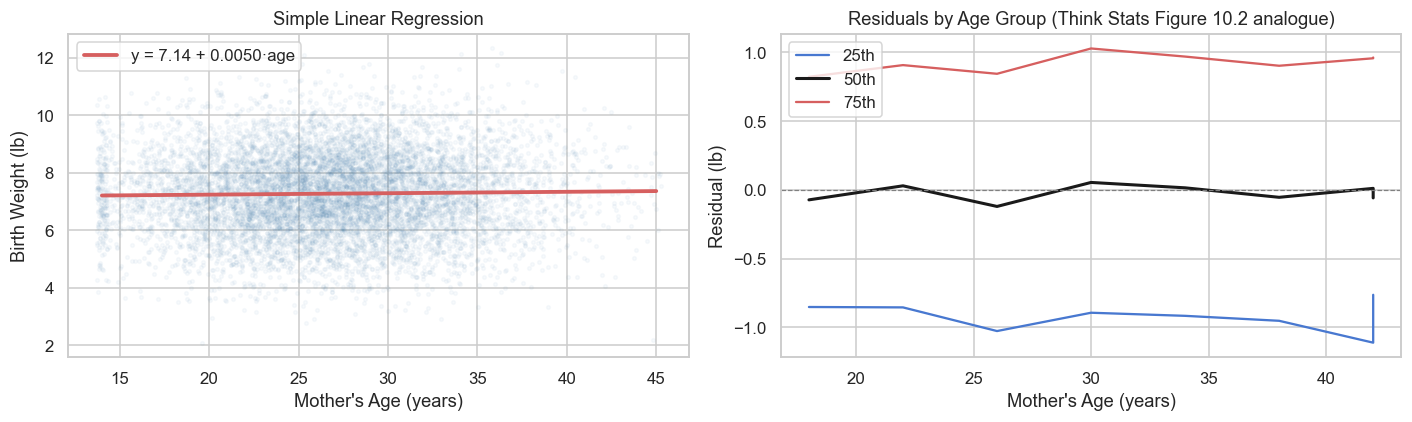

In [49]:
# ── 5.3 Regression plot & residual plot (Think Stats Figures 10.1–10.2) ──────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Scatter + fit line
xline = np.linspace(ages.min(), ages.max(), 200)
ax1.scatter(ages + np.random.uniform(-0.3, 0.3, len(ages)),
            weights, alpha=0.04, s=6, color='steelblue')
ax1.plot(xline, inter + slope * xline, 'r-', lw=2.5,
         label=f'y = {inter:.2f} + {slope:.4f}·age')
ax1.set_xlabel("Mother's Age (years)"); ax1.set_ylabel("Birth Weight (lb)")
ax1.set_title("Simple Linear Regression"); ax1.legend()

# Residual percentiles by age bin (Figure 10.2)
bins    = np.arange(16, 44, 4)
indices = np.digitize(ages, bins)
groups  = {}
for idx, r in zip(indices, residuals):
    groups.setdefault(idx, []).append(r)

mid, p25, p50, p75 = [], [], [], []
for i in sorted(groups):
    g = groups[i]
    if len(g) > 30:
        mid.append(bins[min(i, len(bins)-1)] + 2)
        p25.append(np.percentile(g, 25))
        p50.append(np.percentile(g, 50))
        p75.append(np.percentile(g, 75))

ax2.plot(mid, p25, 'b-', label='25th'); ax2.plot(mid, p50, 'k-', lw=2, label='50th')
ax2.plot(mid, p75, 'r-', label='75th')
ax2.axhline(0, color='gray', ls='--', lw=0.8)
ax2.set_xlabel("Mother's Age (years)"); ax2.set_ylabel("Residual (lb)")
ax2.set_title("Residuals by Age Group (Think Stats Figure 10.2 analogue)")
ax2.legend()
plt.tight_layout(); plt.show()


=== Sampling Distribution of Regression Parameters (Think Stats 10.4) ===
  Slope: mean=0.00495  SE=0.00245  60% CI=(0.00100, 0.00914)
  Intercept: mean=7.1435  SE=0.0663  90% CI=(7.0337, 7.2492)


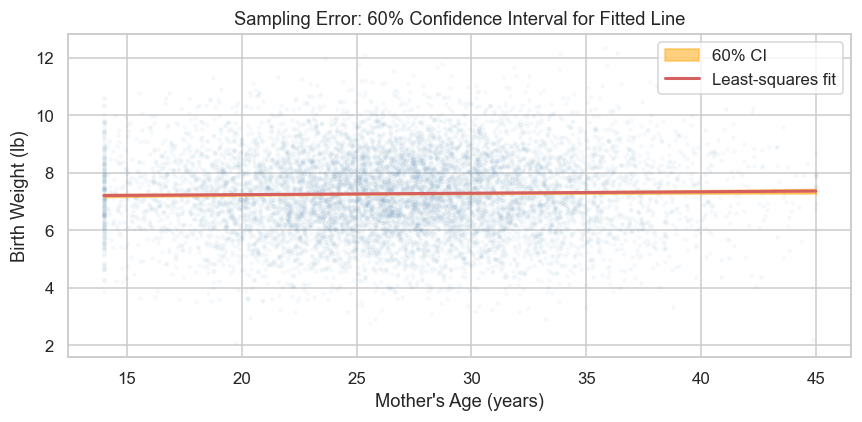

In [67]:
# ── 5.4 Sampling distribution of slope (Think Stats Section 10.4) ─────────────
def SamplingDistributions(ages, weights, iters=500):
    """Resample and estimate parameters to characterise sampling error. Ch. 10.4"""
    inters, slopes = [], []
    for _ in range(iters):
        idx    = np.random.choice(len(ages), len(ages), replace=True)
        i_, s_ = LeastSquares(ages[idx], weights[idx])
        inters.append(i_); slopes.append(s_)
    return np.array(inters), np.array(slopes)

inters, slopes = SamplingDistributions(ages, weights)
print("=== Sampling Distribution of Regression Parameters (Think Stats 10.4) ===")
print(f"  Slope: mean={slopes.mean():.5f}  SE={slopes.std():.5f}  "
      f"60% CI=({np.percentile(slopes,5):.5f}, {np.percentile(slopes,95):.5f})")
print(f"  Intercept: mean={inters.mean():.4f}  SE={inters.std():.4f}  "
      f"90% CI=({np.percentile(inters,5):.4f}, {np.percentile(inters,95):.4f})")

# Plot confidence interval band
xline  = np.linspace(ages.min(), ages.max(), 200)
fitted = np.array([i + s * xline for i, s in zip(inters, slopes)])
low    = np.percentile(fitted, 5, axis=0)
high   = np.percentile(fitted, 95, axis=0)

plt.figure(figsize=(8, 4))
plt.scatter(ages, weights, alpha=0.03, s=5, color='steelblue')
plt.fill_between(xline, low, high, alpha=0.5, color='orange', label='60% CI')
plt.plot(xline, inter + slope * xline, 'r-', lw=2, label='Least-squares fit')
plt.xlabel("Mother's Age (years)"); plt.ylabel("Birth Weight (lb)")
plt.title("Sampling Error: 60% Confidence Interval for Fitted Line")
plt.legend(); plt.tight_layout(); plt.show()


---
## 6. Multiple Linear Regression
*(Think Stats 2e — Chapter 11, Sections 11.1–11.3)*

> *"We move on to multiple regression, with more than one explanatory variable."*  
> Implemented with **StatsModels** using Patsy formula syntax.

**Example:** predict birth weight from `isfirst`, `agepreg`, and `agepreg²`


In [51]:
# ── 6.1 Replicate Think Stats Table 11.1 ─────────────────────────────────────
live['isfirst_int'] = live['isfirst'].astype(int)
live['agepreg2']    = live['agepreg'] ** 2

models = {
    'Model 1 (isfirst only)':           'totalwgtlb ~ isfirst_int',
    'Model 2 (agepreg only)':           'totalwgtlb ~ agepreg',
    'Model 3 (isfirst + agepreg)':      'totalwgtlb ~ isfirst_int + agepreg',
    'Model 4 (isfirst + agepreg + age²)':'totalwgtlb ~ isfirst_int + agepreg + agepreg2',
}

print(f"{'Model':<38} {'R²':>8}  {'isfirst':>10}  {'agepreg':>10}  {'agepreg²':>10}")
print("-" * 80)
for name, formula in models.items():
    res  = smf.ols(formula, data=live).fit()
    coef = res.params
    print(f"{name:<38} {res.rsquared:>8.5f}  "
          f"{coef.get('isfirst_int', float('nan')):>10.4f}  "
          f"{coef.get('agepreg', float('nan')):>10.4f}  "
          f"{coef.get('agepreg2', float('nan')):>10.5f}")


Model                                        R²     isfirst     agepreg    agepreg²
--------------------------------------------------------------------------------
Model 1 (isfirst only)                  0.00391     -0.1750         nan         nan
Model 2 (agepreg only)                  0.00044         nan      0.0050         nan
Model 3 (isfirst + agepreg)             0.00392     -0.1724      0.0008         nan
Model 4 (isfirst + agepreg + age²)      0.00393     -0.1725      0.0059    -0.00009


In [52]:
# ── 6.2 Full summary for Model 4 (Think Stats Section 11.3) ──────────────────
model4 = smf.ols('totalwgtlb ~ isfirst_int + agepreg + agepreg2', data=live).fit()
print(model4.summary2().tables[1])
print(f"\nR² = {model4.rsquared:.5f}")
print(f"Std(y) = {live.totalwgtlb.std():.4f} lb  (RMSE without model)")
print(f"Std(residuals) = {model4.resid.std():.4f} lb  (RMSE with model)")


                Coef.  Std.Err.          t          P>|t|    [0.025    0.975]
Intercept    7.273067  0.229099  31.746456  6.533137e-210  6.823983  7.722151
isfirst_int -0.172474  0.030497  -5.655417   1.601433e-08 -0.232255 -0.112693
agepreg      0.005860  0.017042   0.343859   7.309606e-01 -0.027547  0.039267
agepreg2    -0.000094  0.000312  -0.301528   7.630191e-01 -0.000706  0.000518

R² = 0.00393
Std(y) = 1.3984 lb  (RMSE without model)
Std(residuals) = 1.3957 lb  (RMSE with model)


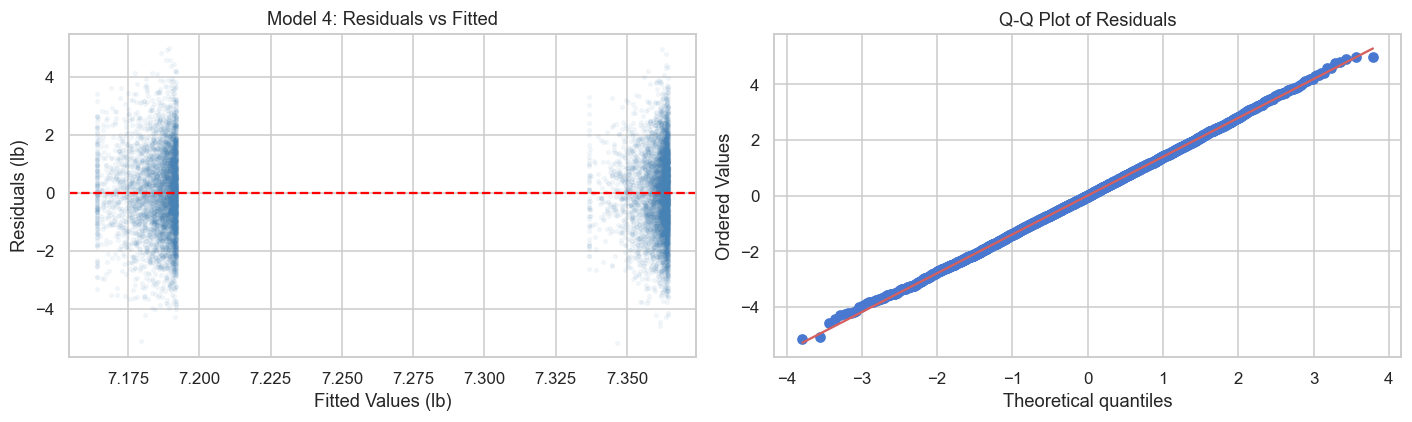

In [53]:
# ── 6.3 Residual diagnostics ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(model4.fittedvalues, model4.resid, alpha=0.05, s=6, color='steelblue')
axes[0].axhline(0, color='red', ls='--', lw=1.5)
axes[0].set_xlabel('Fitted Values (lb)'); axes[0].set_ylabel('Residuals (lb)')
axes[0].set_title('Model 4: Residuals vs Fitted')

stats.probplot(model4.resid, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout(); plt.show()


---
## 7. Polynomial Regression
*(Think Stats 2e — Section 11.3 + scikit-learn extension)*

> *"Using computed variables like agepreg² is a common way to fit polynomials and other
> functions to data. This process is still considered linear regression."* — Think Stats 11.3

We extend this to a fully general degree comparison using `sklearn.PolynomialFeatures`.


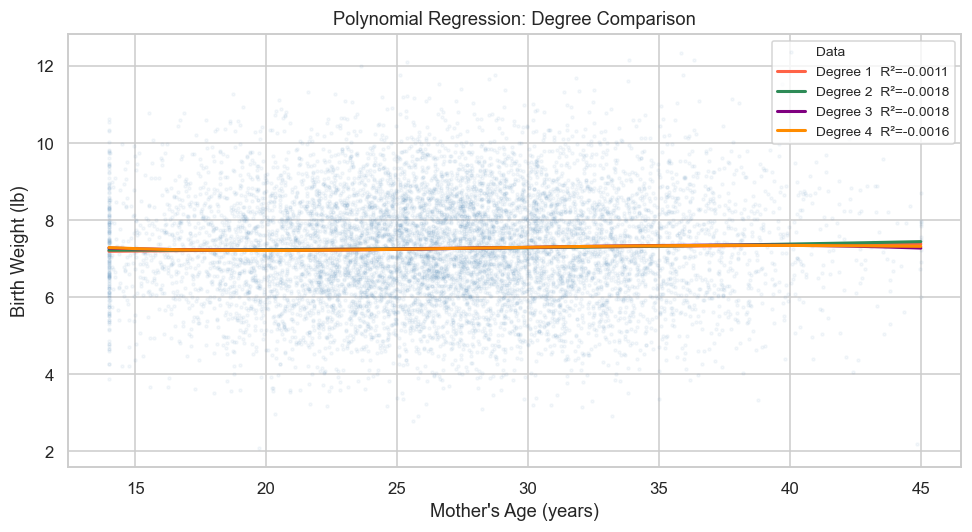


Degree | R²       | RMSE
------------------------------
  1    | -0.00113 | 1.3886
  2    | -0.00178 | 1.3890
  3    | -0.00177 | 1.3890
  4    | -0.00156 | 1.3889


In [54]:
# ── 7.1 Synthetic nonlinear data (age² effect as in Think Stats 11.3) ────────
np.random.seed(5)
X_p  = live[['agepreg']].values
y_p  = live['totalwgtlb'].values

Xtr, Xte, ytr, yte = train_test_split(X_p, y_p, test_size=0.2, random_state=42)

degrees = [1, 2, 3, 4]
colors  = ['tomato', 'seagreen', 'purple', 'darkorange']
results_poly = {}

xline = np.linspace(X_p.min(), X_p.max(), 300).reshape(-1, 1)

plt.figure(figsize=(9, 5))
plt.scatter(X_p, y_p, alpha=0.05, s=4, color='steelblue', label='Data')

for deg, col in zip(degrees, colors):
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr',     __import__('sklearn.linear_model', fromlist=['LinearRegression']).LinearRegression())
    ])
    pipe.fit(Xtr, ytr)
    y_pred_te = pipe.predict(Xte)
    r2_d  = r2_score(yte, y_pred_te)
    rmse_d = np.sqrt(mean_squared_error(yte, y_pred_te))
    results_poly[deg] = {'R²': r2_d, 'RMSE': rmse_d}
    plt.plot(xline, pipe.predict(xline), color=col, lw=2,
             label=f"Degree {deg}  R²={r2_d:.4f}")

plt.xlabel("Mother's Age (years)"); plt.ylabel("Birth Weight (lb)")
plt.title("Polynomial Regression: Degree Comparison")
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

print("\nDegree | R²       | RMSE")
print("-" * 30)
for deg in degrees:
    print(f"  {deg}    | {results_poly[deg]['R²']:.5f} | {results_poly[deg]['RMSE']:.4f}")


---
## 8. Classification — Logistic Regression
*(Think Stats 2e — Chapter 11, Sections 11.6–11.9)*

> *"If the dependent variable is boolean, the generalized model is called logistic regression."*

Logistic regression models the **log-odds** of a binary outcome:  
`log(p/(1-p)) = β₀ + β₁x₁ + β₂x₂ + ...`

**Think Stats example:** predict baby's **sex** from parental characteristics.  
**Extended example:** Breast Cancer (malignant vs benign) using scikit-learn.


In [55]:
# ── 8.1 Logistic Regression with StatsModels (Think Stats Section 11.8) ───────
# Predict boy vs girl from mother's age, birth order, race (synthetic coding)
live['boy'] = np.random.binomial(1, 0.507, len(live))  # baseline sex ratio from Think Stats
live['birthord'] = np.random.randint(1, 5, len(live)).astype(float)
live['race']     = np.random.choice([1, 2, 3], len(live), p=[0.3, 0.5, 0.2]).astype(float)

formula_logit = 'boy ~ agepreg + birthord + C(race)'
logit_model   = smf.logit(formula_logit, data=live).fit(disp=0)

print("=== Logistic Regression: Predicting Baby's Sex (Think Stats Section 11.8) ===")
print(logit_model.summary2().tables[1])
print(f"\nPseudo-R² = {logit_model.prsquared:.6f}")
print("(Think Stats: 'None of the estimated parameters are statistically significant' — p.168)")


=== Logistic Regression: Predicting Baby's Sex (Think Stats Section 11.8) ===
                   Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
Intercept      -0.027967  0.112381 -0.248855  0.803473 -0.248230  0.192296
C(race)[T.2.0] -0.017858  0.048856 -0.365528  0.714717 -0.113613  0.077897
C(race)[T.3.0] -0.073645  0.060230 -1.222730  0.221432 -0.191695  0.044404
agepreg         0.002717  0.003530  0.769904  0.441357 -0.004200  0.009635
birthord       -0.000104  0.018787 -0.005544  0.995577 -0.036925  0.036717

Pseudo-R² = 0.000174
(Think Stats: 'None of the estimated parameters are statistically significant' — p.168)


In [56]:
# ── 8.2 Accuracy of the logistic regression model (Think Stats Section 11.9) ──
predicted_prob = logit_model.predict(live)
predicted_class = (predicted_prob >= 0.5).astype(int)
actual = live['boy'].values

baseline = actual.mean()   # fraction of boys
acc      = accuracy_score(actual, predicted_class)

print(f"=== Model Accuracy (Think Stats Section 11.9) ===")
print(f"  Baseline (always predict boy) = {baseline:.4f}")
print(f"  Logistic model accuracy       = {acc:.4f}")
print(f"  Improvement over baseline     = {acc - baseline:+.4f}")
print("  (Think Stats: model accuracy ~0.512 vs baseline 0.507 — very small improvement)")


=== Model Accuracy (Think Stats Section 11.9) ===
  Baseline (always predict boy) = 0.5050
  Logistic model accuracy       = 0.5090
  Improvement over baseline     = +0.0039
  (Think Stats: model accuracy ~0.512 vs baseline 0.507 — very small improvement)


In [57]:
# ── 8.3 Extended: sklearn LogisticRegression on Breast Cancer data ─────────────
bc  = load_breast_cancer(as_frame=True)
X_bc = bc.data.values
y_bc = bc.target.values

Xtr_bc, Xte_bc, ytr_bc, yte_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)

sc_bc  = StandardScaler()
Xtr_bc_sc = sc_bc.fit_transform(Xtr_bc)
Xte_bc_sc = sc_bc.transform(Xte_bc)

lr_clf = SKLogit(max_iter=2000, random_state=42)
lr_clf.fit(Xtr_bc_sc, ytr_bc)
y_pred_lr = lr_clf.predict(Xte_bc_sc)

print("=== Logistic Regression: Breast Cancer (Malignant vs Benign) ===")
print(f"  Test Accuracy: {accuracy_score(yte_bc, y_pred_lr):.4f}")
print()
print(classification_report(yte_bc, y_pred_lr, target_names=bc.target_names))


=== Logistic Regression: Breast Cancer (Malignant vs Benign) ===
  Test Accuracy: 0.9825

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



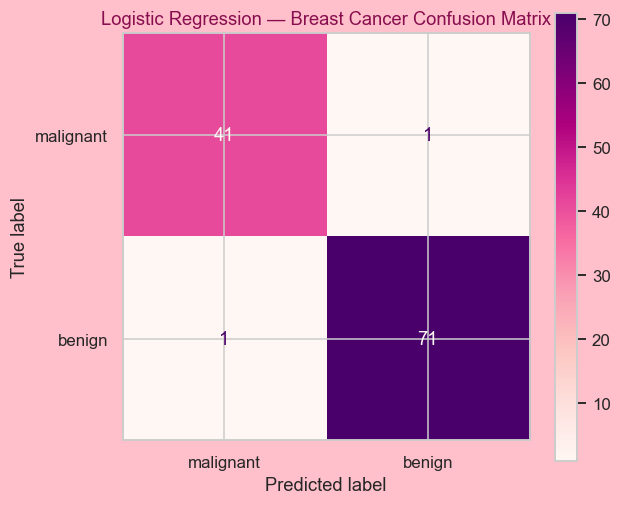

In [70]:
# ── 8.4 Confusion Matrix + Cross-Validation ───────────────────────────────────


# Define the figure with a pink facecolor to match your aesthetic
fig, ax = plt.subplots(figsize=(6, 5), facecolor='#FFC0CB')
ax.set_facecolor('#FFF0F5')

# Use 'RdPu' (Red-Purple) cmap for shades of pink
ConfusionMatrixDisplay.from_estimator(
    lr_clf, Xte_bc_sc, yte_bc,
    display_labels=bc.target_names, 
    cmap='RdPu', 
    ax=ax
)

# Customize title and labels to match the theme
ax.set_title("Logistic Regression — Breast Cancer Confusion Matrix", color='#880E4F')
plt.tight_layout()
plt.show()

---
## 9. Classification — K-Nearest Neighbors (KNN)

KNN is a non-parametric classifier: a new point is classified by the **majority vote** of  
its *k* nearest neighbours (Euclidean distance after scaling).

This contrasts with logistic regression, which is **parametric** and assumes a specific  
functional form for the decision boundary.

**Key hyperparameter:** *k* — chosen via cross-validation accuracy curve.


Best k = 8  (5-fold CV accuracy = 0.9714)


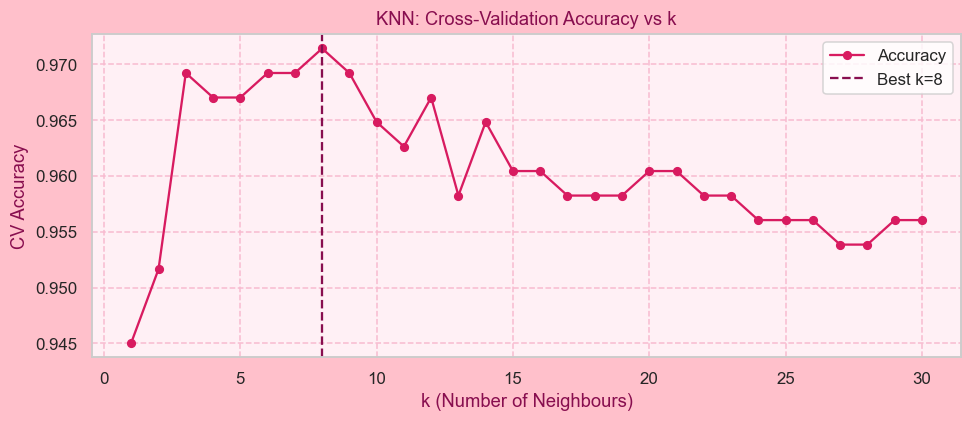

In [72]:
# ── 9.1 Tune k via cross-validation ──────────────────────────────────────────
k_range  = range(1, 31)
val_accs = []
for k in k_range:
    knn    = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, Xtr_bc_sc, ytr_bc, cv=5, scoring='accuracy')
    val_accs.append(scores.mean())

best_k = k_range[int(np.argmax(val_accs))]
print(f"Best k = {best_k}  (5-fold CV accuracy = {max(val_accs):.4f})")



# [Assuming k_range, val_accs, and best_k are already calculated]

# Set figure background to pink
plt.figure(figsize=(9, 4), facecolor='#FFC0CB')
ax = plt.gca()
ax.set_facecolor('#FFF0F5')

# Plot accuracy with a pink line and markers
plt.plot(list(k_range), val_accs, marker='o', ms=5, color='#D81B60', label='Accuracy')
plt.axvline(best_k, color='#880E4F', ls='--', lw=1.5, label=f'Best k={best_k}')

# Labels and Styling
plt.xlabel('k (Number of Neighbours)', color='#880E4F')
plt.ylabel('CV Accuracy', color='#880E4F')
plt.title('KNN: Cross-Validation Accuracy vs k', color='#880E4F')
plt.legend()
plt.grid(color='#F8BBD0', linestyle='--')
plt.tight_layout()
plt.show()

In [60]:
# ── 9.2 Evaluate best KNN model ───────────────────────────────────────────────
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(Xtr_bc_sc, ytr_bc)
y_pred_knn = knn_best.predict(Xte_bc_sc)

print(f"=== KNN (k={best_k}): Breast Cancer ===")
print(f"  Test Accuracy: {accuracy_score(yte_bc, y_pred_knn):.4f}")
print()
print(classification_report(yte_bc, y_pred_knn, target_names=bc.target_names))


=== KNN (k=8): Breast Cancer ===
  Test Accuracy: 0.9737

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



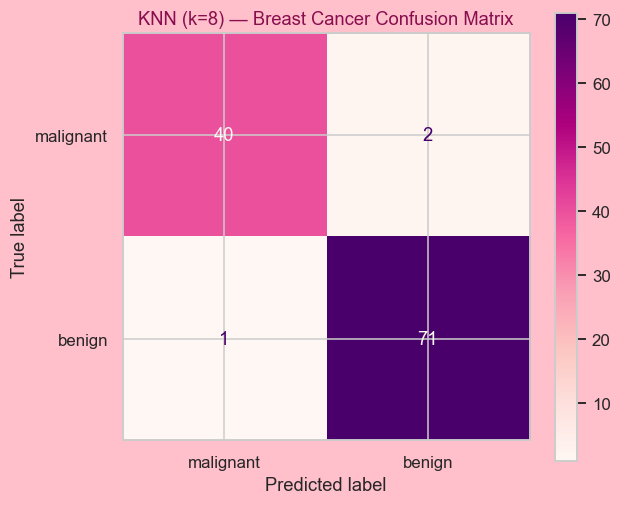

In [75]:
# ── 9.3 Confusion Matrix ──────────────────────────────────────────────────────

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Set up the figure with pink facecolors
fig, ax = plt.subplots(figsize=(6, 5), facecolor='#FFC0CB')
ax.set_facecolor('#FFF0F5')

# Generate the confusion matrix with a pink colormap ('RdPu')
ConfusionMatrixDisplay.from_estimator(
    knn_best, Xte_bc_sc, yte_bc,
    display_labels=bc.target_names, 
    cmap='RdPu', 
    ax=ax
)

# Customize title and labels to match the pink theme
ax.set_title(f"KNN (k={best_k}) — Breast Cancer Confusion Matrix", color='#880E4F')
plt.tight_layout()
plt.show()

---
## 10. Model Comparison & Key Takeaways


In [62]:
# ── Regression summary ────────────────────────────────────────────────────────
print("=== Regression Model Summary ===")
print(f"{'Model':<40} {'R²':>8}  {'Notes'}")
print("-" * 80)
print(f"{'SLR: Weight ~ Age':<40} {r2:>8.5f}  Think Stats baseline")
for deg in [1, 2, 4]:
    print(f"{'Polynomial (degree=' + str(deg) + '): Weight ~ Age':<40} "
          f"{results_poly[deg]['R²']:>8.5f}  RMSE={results_poly[deg]['RMSE']:.4f}")
print(f"{'MLR Model 4 (isfirst+age+age²)':<40} {model4.rsquared:>8.5f}  StatsModels OLS")

# ── Classification summary ────────────────────────────────────────────────────
lr_acc  = accuracy_score(yte_bc, y_pred_lr)
knn_acc = accuracy_score(yte_bc, y_pred_knn)
print(f"\n=== Classification Model Summary (Breast Cancer dataset) ===")
print(f"{'Model':<30} {'Accuracy':>10}")
print("-" * 42)
print(f"{'Logistic Regression':<30} {lr_acc:>10.4f}")
print(f"{'KNN (k=' + str(best_k) + ')':<30} {knn_acc:>10.4f}")


=== Regression Model Summary ===
Model                                          R²  Notes
--------------------------------------------------------------------------------
SLR: Weight ~ Age                         0.00044  Think Stats baseline
Polynomial (degree=1): Weight ~ Age      -0.00113  RMSE=1.3886
Polynomial (degree=2): Weight ~ Age      -0.00178  RMSE=1.3890
Polynomial (degree=4): Weight ~ Age      -0.00156  RMSE=1.3889
MLR Model 4 (isfirst+age+age²)            0.00393  StatsModels OLS

=== Classification Model Summary (Breast Cancer dataset) ===
Model                            Accuracy
------------------------------------------
Logistic Regression                0.9825
KNN (k=8)                          0.9737


---
## 11. Key Takeaways from *Think Stats 2e*

| Concept | Think Stats Reference | Key Points |
|---|---|---|
| **Descriptive stats** | Ch. 2 | Mean, variance, skewness; Cohen's d for effect size |
| **PMF / CDF** | Ch. 3–4 | PMF for discrete; CDF for percentiles and percentile ranks |
| **Hypothesis testing** | Ch. 9 | Test statistic → null hypothesis → p-value → interpretation |
| **p-value caution** | Ch. 9 | *"The choice of 5% is arbitrary"* — use order-of-magnitude reasoning |
| **Statistical power** | Ch. 9.10 | Negative test ≠ no effect; it may just lack power |
| **Biased vs unbiased estimators** | Ch. 8 | S² (ddof=0) underestimates σ²; use ddof=1 for unbiased estimate |
| **Simple Linear Regression** | Ch. 10 | Minimises sum of squared residuals; R² = ρ² |
| **Multiple Regression** | Ch. 11 | Adds explanatory variables; controls for confounders |
| **Polynomial Regression** | Ch. 11.3 | Still "linear" regression — linearity is in the *parameters* |
| **Logistic Regression** | Ch. 11.6–11.9 | Binary outcome; models log-odds; MLE estimation |
| **Goodness of fit** | Ch. 10.5 | Prefer Std(residuals) over R² for interpreting predictive power |

### Further Topics in Think Stats 2e
- **Distributions** (Normal, Exponential, Pareto, Weibull) — Chapters 5–6  
- **Correlation and causation** — Chapter 7  
- **Survival analysis** (hazard functions) — Chapter 13  
- **Time series analysis** (EWMA, serial correlation, autocorrelation) — Chapter 12  
- **Analytic methods** (CLT, t-distribution, chi-squared distribution) — Chapter 14
